# 07. Electric Boilers & Peak Shaving

Model 06 sized the heat pump generously enough that it could cover heat demand on its own, with the
thermal store only smoothing out timing. This model introduces a more realistic constraint: the heat
pump is now **undersized relative to peak demand**, and a second, thermodynamically inferior device —
a simple electric boiler — is added to cover the gap.

The objective is to extend the Model 06 system, but with the heat pump's electrical input capacity
reduced to **1 MW** (delivering at most 3.5 MW of heat at COP 3.5) against a heat demand that peaks
at 5 MW. A **5 MW electric boiler** — a plain resistive heater with no COP multiplier — is added
alongside it on `heat_bus` to cover whatever the heat pump and thermal store can't.

## 🛠️ System Topology
1. **Buses:** `electricity_bus` and `heat_bus`, unchanged from Model 06.
2. **Generators (Source):** Solar PV (10 MW) and Wind (15 MW), unchanged.
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, unchanged.
4. **Loads:** `Industrial_Load` and `Heat_Demand`, unchanged.
5. **Storage:** `Battery` and `Thermal_Storage`, unchanged.
6. **Links:** `Heat_Pump` (now capacity-reduced to 1 MW electrical input) and a new `Electric_Boiler`
   — electricity in, heat out, `efficiency≈1.0` (a resistive heater converts electricity to heat
   almost losslessly, but without the COP multiplier that makes a heat pump so much more
   electricity-efficient).

### Why the boiler is a backup, not a replacement
A heat pump delivers 3.5 MWh of heat per MWh of electricity; a boiler delivers roughly 1 MWh of heat
per MWh of electricity. Given a choice, the solver will always prefer the heat pump — it needs less
electricity (and therefore less `Grid_Import` cost) to deliver the same heat. The boiler only gets
used in two situations: **(1) peak shaving**, when demand or a thermal-store deficit exceeds what the
heat pump's limited capacity can supply, and **(2) opportunistically during very cheap or negative
electricity prices**, where the efficiency penalty barely matters because the electricity itself costs
almost nothing.

<img src="../assets/model_7.jpg" alt="Model 07 System Topology" width="800">


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

All electricity-side and thermal-storage parameters are carried over unchanged from Model 06. The
`heat_pump` capacity is reduced from Model 06's 3 MW down to 1 MW, and a new `electric_boiler` entry
is added.


In [2]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh
    },
    'wind': {
        'p_nom': 15.0,          # Nominal capacity of the wind plant in MW
        'marginal_cost': 0.0    # Marginal cost of wind generation in $/MWh
    },
    'market_grid': {
        'import_p_nom': 20.0,   # Maximum import capacity from the grid
        'export_p_nom': 18.0    # Maximum export capacity to the grid
    },
    'demand': {
        'day_load_mw': 8.0,     # Electrical load during working hours (08:00-18:00)
        'night_load_mw': 4.0    # Electrical load outside working hours
    },
    'battery': {
        'p_nom': 4.0,                # Charge/discharge power rating in MW
        'max_hours': 2.0,            # Duration -> 4 MW x 2h = 8 MWh usable capacity
        'efficiency_store': 0.95,    # Charging efficiency
        'efficiency_dispatch': 0.95  # Discharging efficiency (round-trip ~ 90%)
    },
    'heat_pump': {
        'p_nom': 1.0,            # Electrical input rating in MW (reduced vs. Model 06 -> now undersized)
        'cop': 3.5,              # Coefficient of Performance (fixed)
        'marginal_cost': 0.5     # Small O&M cost per MWh of heat output
    },
    'electric_boiler': {
        'p_nom': 5.0,            # Electrical input rating in MW
        'efficiency': 0.99,      # Resistive heating - almost no conversion loss, but no COP multiplier
        'marginal_cost': 1.0     # Slightly higher O&M cost per MWh, reinforcing it as the "last resort"
    },
    'heat_demand': {
        'avg_mw': 3.0,           # Average district heating demand
        'amplitude_mw': 2.0      # Seasonal swing around the average (winter-high)
    },
    'thermal_storage': {
        'e_nom': 40.0,           # Usable energy capacity in MWh
        'standing_loss': 0.01    # Hourly self-discharge (heat loss to surroundings)
    }
}


## 🏗️ Initializing the Network

The topology is unchanged from Model 06 — still `electricity_bus` and `heat_bus`. The boiler, added
later, is simply a second link into `heat_bus` alongside the heat pump.


In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add both energy-carrier buses
n.add("Bus", "electricity_bus")
n.add("Bus", "heat_bus")


Index(['heat_bus'], dtype='object')

## ⚡ Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are added exactly as in Model 06.


In [4]:
# 1. Add the Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Add the Wind generator
n.add("Generator",
      "Wind",
      bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Add the Grid Import generator (covers any shortfall)
n.add("Generator",
      "Grid_Import",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

# 4. Add the Grid Export Market Sink (sells any surplus)
n.add("Generator",
      "Grid_Export",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical and Heat Demands

Unchanged from Models 05-06.


In [5]:
# Electrical load: same day/night industrial shape as Models 03-06
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
electrical_load = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
electrical_load = pd.Series(electrical_load, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=electrical_load)

# Heat load: same seasonal (winter-high) shape as Models 05-06
day_of_year = n.snapshots.dayofyear
heat_load = tech_param['heat_demand']['avg_mw'] - tech_param['heat_demand']['amplitude_mw'] * np.sin(
    (day_of_year - 80) * 2 * np.pi / 365
)
heat_load = pd.Series(np.clip(heat_load, 0.2, None), index=n.snapshots)

n.add("Load", "Heat_Demand", bus="heat_bus", p_set=heat_load)

print(f"Heat demand peak: {heat_load.max():.2f} MW vs. Heat Pump max output: {tech_param['heat_pump']['p_nom'] * tech_param['heat_pump']['cop']:.2f} MW")


Heat demand peak: 5.00 MW vs. Heat Pump max output: 3.50 MW


## 🔋 Adding the Battery, 🌡️ the Thermal Store, and 🔗 the Heat Pump

All unchanged in structure from Model 06 — only the heat pump's `p_nom` has been reduced, per the
updated `tech_param` dictionary above.


In [6]:
n.add("StorageUnit",
      "Battery",
      bus="electricity_bus",
      p_nom=tech_param['battery']['p_nom'],
      max_hours=tech_param['battery']['max_hours'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)

n.add("Store",
      "Thermal_Storage",
      bus="heat_bus",
      e_nom=tech_param['thermal_storage']['e_nom'],
      e_cyclic=True,
      standing_loss=tech_param['thermal_storage']['standing_loss'])

n.add("Link",
      "Heat_Pump",
      bus0="electricity_bus",
      bus1="heat_bus",
      p_nom=tech_param['heat_pump']['p_nom'],
      efficiency=tech_param['heat_pump']['cop'],
      marginal_cost=tech_param['heat_pump']['marginal_cost'])


Index(['Heat_Pump'], dtype='object')

## 🔥 Adding the Electric Boiler

The boiler is structurally identical to the heat pump — a `Link` from `electricity_bus` to
`heat_bus` — but with `efficiency` set close to 1.0 instead of a COP, and a slightly higher
`marginal_cost` to reflect that it's the less desirable option whenever the heat pump has spare
capacity. The solver will still use it eagerly whenever the heat pump alone can't keep up.


In [7]:
n.add("Link",
      "Electric_Boiler",
      bus0="electricity_bus",
      bus1="heat_bus",
      p_nom=tech_param['electric_boiler']['p_nom'],
      efficiency=tech_param['electric_boiler']['efficiency'],
      marginal_cost=tech_param['electric_boiler']['marginal_cost'])


Index(['Electric_Boiler'], dtype='object')

## 🧠 Running the Optimization

With two competing heat sources now in the network, the solver has to decide, hour by hour, how to
split heat production between the efficient-but-capacity-limited heat pump and the
inefficient-but-flexible boiler, alongside everything else.


In [8]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost, Import minus Export Revenue): €{n.objective:,.2f}")


Index(['Heat_Pump', 'Electric_Boiler'], dtype='object', name='Link')
Index(['electricity_bus', 'heat_bus'], dtype='object', name='Bus')
Index(['Thermal_Storage'], dtype='object', name='Store')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 24.37it/s]
INFO:linopy.io: Writing time: 1.74s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96360 primals, 210240 duals
Objective: -8.85e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit

Solver Status: ok
Total Objective Value (Net Cost, Import minus Export Revenue): €-885,097.36


## 📊 Analyzing the Results

We split total heat production between the two sources, and check how the boiler's usage lines up
with the heat pump running at its capacity ceiling — the signature of genuine peak shaving.


Heat Pump Output:              20,342.05 MWh (74.3%)
Electric Boiler Output:        7,045.28 MWh (25.7%)
---------------------------------------------
Hours Heat Pump at Capacity:   5545
Hours Boiler Active:           1873
Hours Both Conditions Overlap: 1849 (98.7% of boiler-active hours)


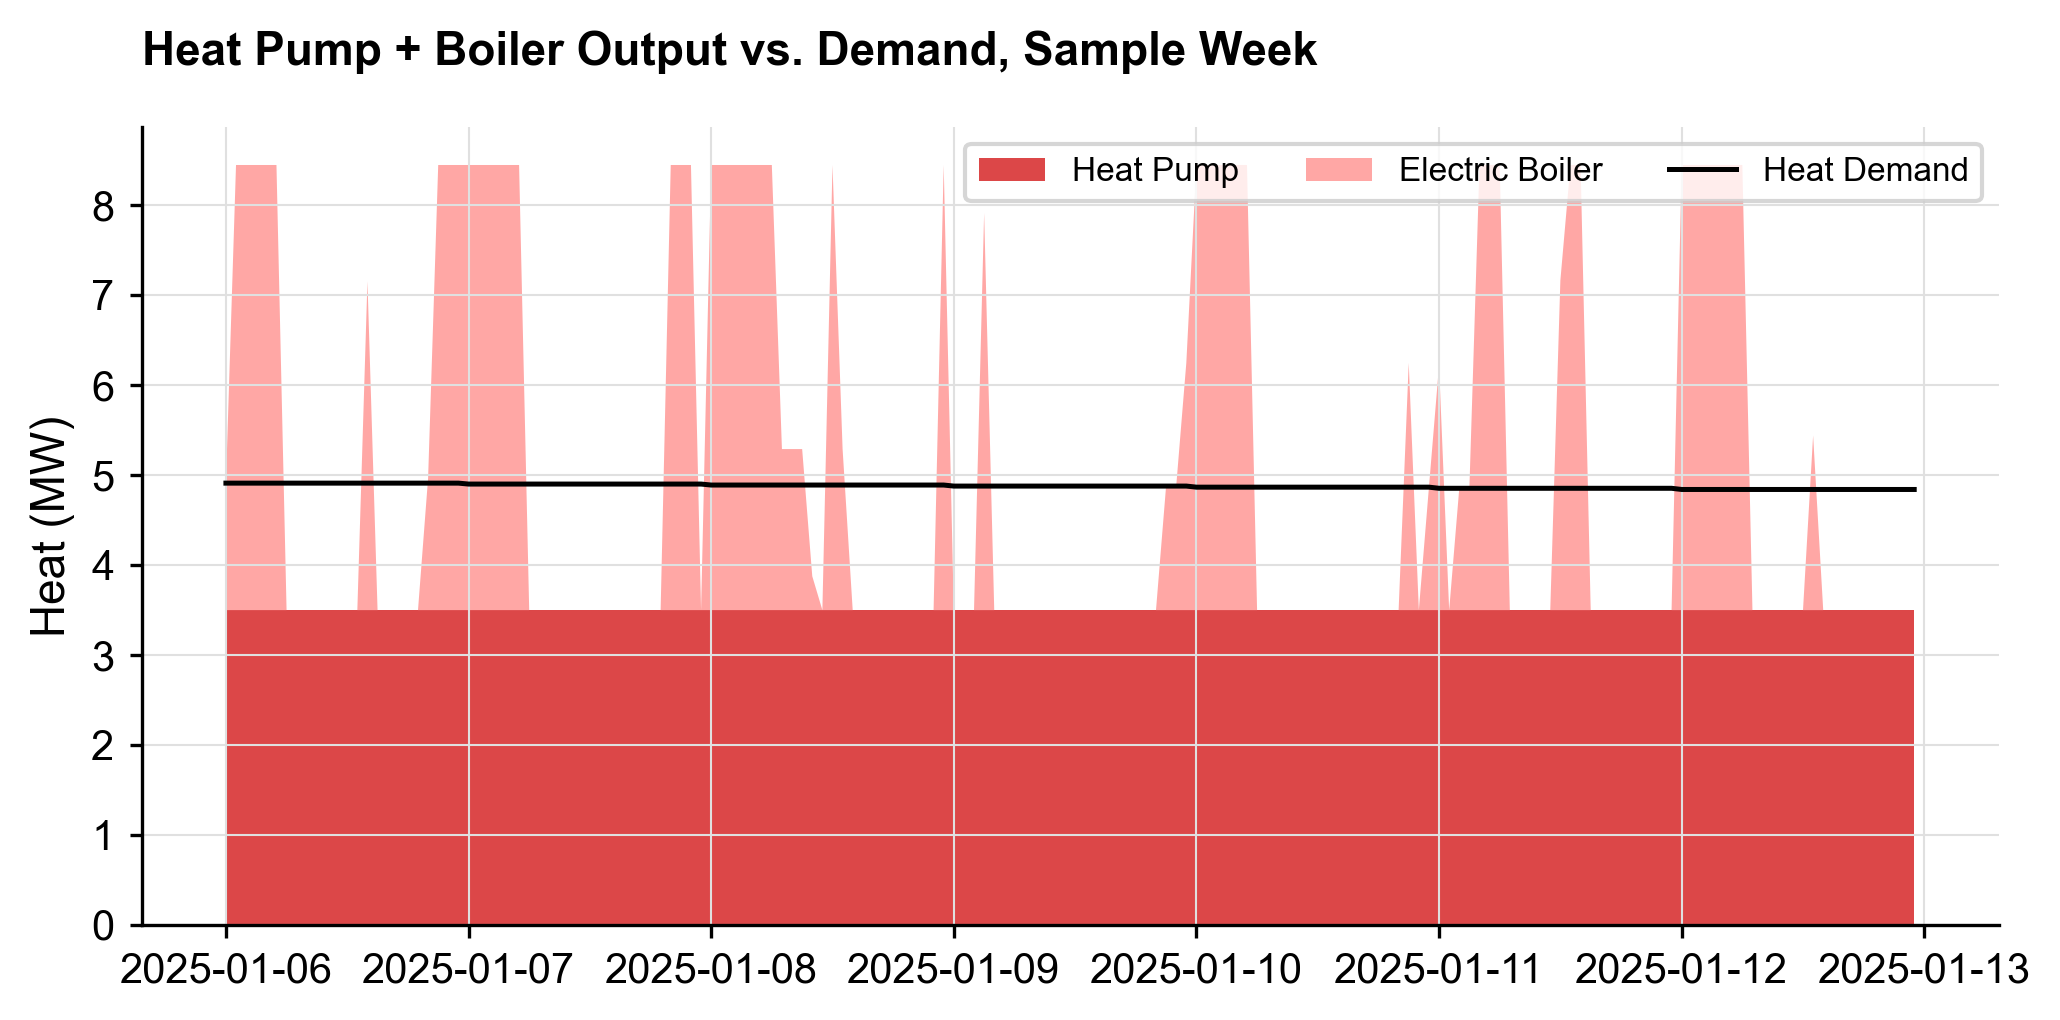

In [9]:
# Calculate Annual Totals
heat_pump_output_mwh = -n.links_t.p1['Heat_Pump'].sum()
boiler_output_mwh = -n.links_t.p1['Electric_Boiler'].sum()
total_heat_output_mwh = heat_pump_output_mwh + boiler_output_mwh

heat_pump_capacity_mw = tech_param['heat_pump']['p_nom'] * tech_param['heat_pump']['cop']
hours_at_hp_ceiling = (n.links_t.p0['Heat_Pump'] >= tech_param['heat_pump']['p_nom'] * 0.99).sum()
hours_boiler_active = (n.links_t.p0['Electric_Boiler'] > 0.01).sum()
hours_both = ((n.links_t.p0['Heat_Pump'] >= tech_param['heat_pump']['p_nom'] * 0.99) & (n.links_t.p0['Electric_Boiler'] > 0.01)).sum()

print(f"Heat Pump Output:              {heat_pump_output_mwh:,.2f} MWh ({100*heat_pump_output_mwh/total_heat_output_mwh:.1f}%)")
print(f"Electric Boiler Output:        {boiler_output_mwh:,.2f} MWh ({100*boiler_output_mwh/total_heat_output_mwh:.1f}%)")
print("-" * 45)
print(f"Hours Heat Pump at Capacity:   {hours_at_hp_ceiling}")
print(f"Hours Boiler Active:           {hours_boiler_active}")
print(f"Hours Both Conditions Overlap: {hours_both} ({100*hours_both/max(hours_boiler_active,1):.1f}% of boiler-active hours)")

# Plot one representative winter week: heat pump vs. boiler output, stacked against demand
week = (n.snapshots >= '2025-01-06') & (n.snapshots < '2025-01-13')

fig, ax = plt.subplots()
ax.stackplot(n.snapshots[week],
             -n.links_t.p1['Heat_Pump'][week],
             -n.links_t.p1['Electric_Boiler'][week],
             labels=['Heat Pump', 'Electric Boiler'],
             colors=['#d62728', '#ff9896'], alpha=0.85)
ax.plot(n.snapshots[week], heat_load[week], color='black', linewidth=1.2, label='Heat Demand')
ax.set_ylabel('Heat (MW)')
ax.set_title('Heat Pump + Boiler Output vs. Demand, Sample Week', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=3, fontsize=8)
plt.tight_layout()
plt.show()
